# Chapter 4 — Regression and Prediction

## Simple Linear Regression

Regression merupakan salah satu metode statistik yang digunakan untuk
mempelajari hubungan antara sebuah response variable dengan satu atau
lebih predictor variables.

Tujuan regression dapat berupa:
- memahami hubungan antara variabel,
- menjelaskan perubahan response variable berdasarkan predictor,
- dan melakukan prediction terhadap response variable.

Dalam data science, regression memiliki hubungan yang erat dengan
prediction. Kita dapat melatih model menggunakan data yang outcome-nya
sudah diketahui, kemudian menggunakan model tersebut untuk melakukan
prediksi pada data yang outcome-nya belum diketahui.

Simple linear regression digunakan ketika kita ingin memodelkan hubungan
antara satu predictor variable dan satu response variable.

### Key Terms in Regression

#### Response
Variabel yang ingin kita prediksi.

Response juga dapat disebut:
- dependent variable
- Y variable
- outcome variable

#### Predictor
Variabel yang digunakan untuk memprediksi response.

Predictor juga dapat disebut:
- independent variable
- X variable
- explanatory variable
- feature

#### Coefficients
Parameter yang menunjukkan bagaimana predictor berhubungan
dengan response.

#### Fitted Values
Nilai response yang diprediksi oleh model regression.

#### Residuals
Perbedaan antara nilai aktual dengan nilai yang diprediksi oleh model.

Residual:

    Residual = Actual Value - Fitted Value

### The Regression Equation

Persamaan dasar simple linear regression:

Y = b0 + b1X + ε

Keterangan:

Y  = response variable
X  = predictor variable
b0 = intercept
b1 = slope
ε  = error

Intercept menunjukkan nilai rata-rata Y ketika X bernilai 0.

Slope menunjukkan perubahan rata-rata Y ketika X meningkat satu unit.

## Fitted Values and Residuals

Setelah regression model dibuat, setiap observasi akan mempunyai
fitted value atau nilai prediksi.

Residual merupakan selisih antara nilai aktual dan fitted value.

Residual = Actual - Fitted

Jika:

Actual  = 100
Fitted  = 95

maka:

Residual = 100 - 95
         = 5

## Least Squares

Regression menggunakan pendekatan least squares untuk menentukan garis
yang paling sesuai dengan data.

Ide dasarnya adalah mencari koefisien regression sehingga jumlah kuadrat
residual menjadi sekecil mungkin.

Residual adalah:

    Actual - Fitted

Kemudian residual tersebut dikuadratkan.

Tujuannya:

    meminimalkan jumlah residual²

## Contoh Simple Linear Regression

In [34]:
!pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 57.0 MB/s eta 0:00:00


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from dmba import stepwise_selection
from dmba import AIC_score
from pygam import LinearGAM, s, l

## Contoh Data

In [2]:
data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5],
    'Y': [2, 4, 5, 4, 6]
})

data

,X,Y
0,1,2
1,2,4
2,3,5
3,4,4
4,5,6


## Membuat Regression Model

In [3]:
model = smf.ols('Y ~ X', data=data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     8.000
Date:                Fri, 02 Oct 2026   Prob (F-statistic):             0.0663
Time:                        16:32:56   Log-Likelihood:                -5.2598
No. Observations:                   5   AIC:                             14.52
Df Residuals:                       3   BIC:                             13.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8000      0.938      1.919      0.1

/usr/local/lib/python3.13/dist-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


## Melihat Koefisien

In [4]:
print("Intercept:", model.params['Intercept'])
print("Slope:", model.params['X'])

Intercept: 1.7999999999999972
Slope: 0.8000000000000004


## Visualisasi Regression Line

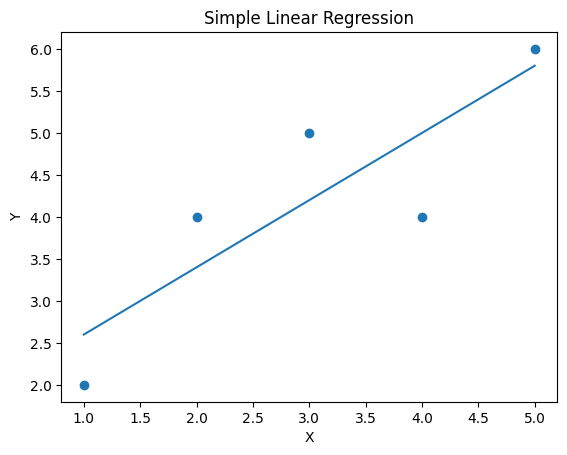

In [5]:
plt.scatter(data['X'], data['Y'])

x_values = np.linspace(data['X'].min(), data['X'].max(), 100)
y_values = model.params['Intercept'] + model.params['X'] * x_values

plt.plot(x_values, y_values)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Simple Linear Regression')
plt.show()

## Prediction Versus Explanation (Profiling)

Regression dapat digunakan untuk dua tujuan yang berbeda.

### Prediction

Tujuannya adalah menghasilkan prediksi yang akurat terhadap response
variable.

Dalam prediction, perhatian utama adalah seberapa baik model dapat
memprediksi data baru.

### Explanation / Profiling

Tujuannya adalah memahami hubungan antara predictor dan response.

Dalam konteks ini, kita lebih memperhatikan bagaimana predictor
berhubungan dengan response dan bagaimana koefisien model dapat
diinterpretasikan.

Model yang berguna untuk prediction tidak selalu menjadi model yang
paling mudah untuk menjelaskan hubungan antarvariabel.

# Multiple Linear Regression

Simple linear regression menggunakan satu predictor untuk menjelaskan
atau memprediksi response.

Multiple linear regression menggunakan dua atau lebih predictor.

Bentuk umum model:

Y = b0 + b1X1 + b2X2 + ... + bpXp + ε

Keterangan:

Y  = response variable
X1, X2, ..., Xp = predictor variables
b0 = intercept
b1, b2, ..., bp = regression coefficients
ε  = error

Dengan multiple linear regression, kita dapat mempertimbangkan beberapa
variabel sekaligus ketika menjelaskan atau memprediksi suatu response.

## Example: King County Housing Data

In [6]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np

house_sales = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv',
    sep='\t'
)

house_sales.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


### King County Housing Data

Data King County digunakan sebagai contoh untuk menunjukkan bagaimana
multiple linear regression dapat digunakan untuk memodelkan harga rumah.

Response variable yang digunakan adalah:

SalePrice

Beberapa predictor dapat digunakan untuk menjelaskan variasi harga rumah,
misalnya ukuran rumah dan karakteristik properti lainnya.

Dengan menggunakan beberapa predictor secara bersamaan, model dapat
memperhitungkan lebih dari satu karakteristik rumah.

## Membuat Multiple Regression Model

In [7]:
model = smf.ols(
    'SalePrice ~ SqFtTotLiving',
    data=house_sales
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                 2.060e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:37:11   Log-Likelihood:            -3.1426e+05
No. Observations:               22687   AIC:                         6.285e+05
Df Residuals:                   22685   BIC:                         6.285e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -3.65e+04   4142.593     -8.810

## Multiple Predictors

In [13]:
# Buat kembali model regression dengan Statsmodels
model = smf.ols(
    'SalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms',
    data=house_sales
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     5509.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:45:51   Log-Likelihood:            -3.1389e+05
No. Observations:               22687   AIC:                         6.278e+05
Df Residuals:                   22682   BIC:                         6.278e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      8.853e+04   6658.394     13.295

### Interpreting Coefficients

Dalam multiple regression, koefisien suatu predictor menunjukkan
hubungan predictor tersebut dengan response setelah predictor lain
dalam model diperhitungkan.

Sebagai contoh, jika koefisien SqFtTotLiving bernilai positif,
maka peningkatan SqFtTotLiving berhubungan dengan peningkatan
predicted SalePrice, dengan predictor lain dalam model tetap.

Koefisien tidak boleh langsung dianggap sebagai hubungan sebab-akibat.
Regression menunjukkan hubungan dalam model, bukan secara otomatis
membuktikan causal relationship.

## Assessing the Model

Setelah model regression dibuat, kita perlu menilai seberapa baik model
tersebut menjelaskan atau memprediksi response.

Dua ukuran yang penting adalah:

### RMSE — Root Mean Squared Error

RMSE mengukur besarnya kesalahan prediksi model.

Semakin kecil RMSE, semakin kecil rata-rata besar error prediksi.

### R² — Coefficient of Determination

R² menunjukkan proporsi variasi response yang dapat dijelaskan oleh
model.

Nilai R² berada antara 0 dan 1 untuk bentuk penggunaan yang umum.

Nilai yang lebih tinggi menunjukkan bahwa model menjelaskan proporsi
variasi response yang lebih besar.

## Menghitung RMSE dan R²

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

predicted = model.predict(house_sales)

rmse = np.sqrt(
    mean_squared_error(house_sales['SalePrice'], predicted)
)

r2 = r2_score(
    house_sales['SalePrice'],
    predicted
)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 246870.5899323349
R²: 0.49276585784894045


### Residual

Residual merupakan perbedaan antara nilai aktual dan nilai yang
diprediksi oleh model.

Residual:

    Actual - Predicted

Residual digunakan untuk melihat pola kesalahan model.

Jika model memiliki pola tertentu pada residual, hal tersebut dapat
menjadi indikasi bahwa model belum menangkap seluruh struktur dalam data.

## Cross-Validation

Cross-validation digunakan untuk menilai bagaimana model kemungkinan
akan bekerja pada data yang belum digunakan dalam fitting.

Ide dasarnya adalah membagi data menjadi beberapa bagian.

Sebagian data digunakan untuk training dan bagian lainnya digunakan
untuk validation.

Proses tersebut dapat diulang sehingga setiap bagian data mendapat
kesempatan menjadi validation set.

Cross-validation membantu memberikan estimasi performa model yang
lebih informatif daripada hanya melihat performa pada data training.

## Cross-Validation

In [10]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

X = house_sales[
    ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms']
]

y = house_sales['SalePrice']

model_cv = LinearRegression()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scores = cross_val_score(
    model_cv,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("R² setiap fold:")
print(scores)

print("\nRata-rata R²:")
print(scores.mean())

R² setiap fold:
[0.52246584 0.4648195  0.5018356  0.4861919  0.49047697]

Rata-rata R²:
0.4931579623587803


## Model Selection and Stepwise Regression

Ketika terdapat banyak predictor, tidak semua predictor harus dimasukkan
ke dalam model.

Model selection digunakan untuk menentukan predictor mana yang akan
digunakan dalam model.

Salah satu pendekatan yang dibahas adalah stepwise regression.

Pada stepwise regression, predictor dapat ditambahkan atau dihilangkan
secara bertahap berdasarkan kriteria tertentu.

Tujuannya adalah mendapatkan model yang lebih sederhana atau lebih sesuai
dengan tujuan analisis.

Pemilihan model harus dilakukan dengan hati-hati karena model yang terlalu
kompleks dapat mengalami overfitting.

### Buat predictor

In [36]:
predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType',
    'NbrLivingUnits',
    'SqFtFinBasement',
    'YrBuilt',
    'YrRenovated',
    'NewConstruction'
]

X = pd.get_dummies(
    house[predictors],
    drop_first=True,
    dtype=int
)

X['NewConstruction'] = [
    1 if nc else 0
    for nc in X['NewConstruction']
]

y = house['AdjSalePrice']

### Buat fungsi train_model

In [37]:
def train_model(variables):
    if len(variables) == 0:
        return None

    model = LinearRegression()
    model.fit(X[variables], y)

    return model

### Buat fungsi score_model

In [38]:
def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(
            y,
            [y.mean()] * len(y),
            model,
            df=1
        )

    return AIC_score(
        y,
        model.predict(X[variables]),
        model
    )

### Jalankan Stepwise Selection

In [39]:
best_model, best_variables = stepwise_selection(
    X.columns,
    train_model,
    score_model,
    verbose=True
)

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None


### Cek hasil best_model

In [40]:
print()

print(f'Intercept: {best_model.intercept_:.3f}')

print('Coefficients:')

for name, coef in zip(
    best_variables,
    best_model.coef_
):
    print(f' {name}: {coef}')


Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


## Weighted Regression

Dalam regression biasa, setiap observasi pada dasarnya memberikan
kontribusi yang sama terhadap proses fitting.

Pada weighted regression, setiap observasi diberikan weight.

Observasi dengan weight yang lebih besar memiliki pengaruh yang lebih
besar terhadap hasil fitting model.

Weighted regression dapat digunakan ketika beberapa observasi dianggap
lebih informatif atau lebih dapat diandalkan dibandingkan observasi lain.

# Prediction Using Regression

Salah satu penggunaan regression adalah melakukan prediction.

Setelah regression model dibuat menggunakan data yang outcome-nya sudah
diketahui, model tersebut dapat digunakan untuk memprediksi outcome dari
data baru.

Dalam prediction, penting untuk memperhatikan apakah nilai predictor pada
data baru masih berada dalam rentang data yang digunakan untuk membangun
model.

Prediction di luar rentang data yang tersedia disebut extrapolation dan
dapat menghasilkan prediksi yang tidak dapat diandalkan.

## The Dangers of Extrapolation

Extrapolation terjadi ketika regression model digunakan untuk melakukan
prediction pada nilai predictor yang berada di luar rentang data yang
digunakan untuk membangun model.

Regression line dapat terlihat masuk akal pada rentang data yang tersedia,
tetapi hubungan tersebut belum tentu terus berlaku di luar rentang tersebut.

Karena itu, extrapolation harus dilakukan dengan hati-hati.

Prediction di dalam rentang data yang digunakan untuk fitting disebut
interpolation, sedangkan prediction di luar rentang tersebut disebut
extrapolation.

## Contoh Visual Extrapolation

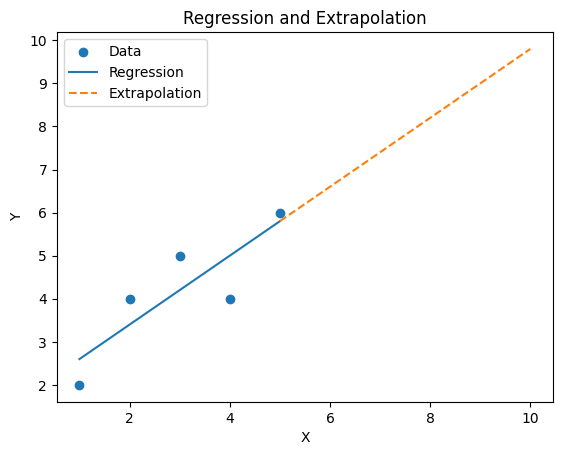

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Data yang digunakan untuk membangun model
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

# Membuat regression line
coef = np.polyfit(x, y, 1)
model = np.poly1d(coef)

# Rentang data yang tersedia
x_inside = np.linspace(1, 5, 100)

# Rentang extrapolation
x_outside = np.linspace(5, 10, 100)

plt.scatter(x, y, label='Data')
plt.plot(x_inside, model(x_inside), label='Regression')
plt.plot(x_outside, model(x_outside), linestyle='--',
         label='Extrapolation')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regression and Extrapolation')
plt.legend()
plt.show()

## Confidence and Prediction Intervals

Regression prediction bukan hanya menghasilkan satu angka.

Kita juga dapat memperkirakan uncertainty dari prediction tersebut.

Dua konsep penting adalah:

1. Confidence interval
2. Prediction interval

Confidence interval digunakan untuk menggambarkan uncertainty
terhadap estimated mean response.

Prediction interval digunakan untuk menggambarkan uncertainty
terhadap individual future observation.

### Confidence Interval

Confidence interval memberikan rentang nilai yang berkaitan dengan
ketidakpastian estimasi mean response pada nilai predictor tertentu.

Karena kita menggunakan sample untuk membangun model, estimasi regression
coefficient dan mean response memiliki uncertainty.

Confidence interval digunakan untuk menggambarkan uncertainty tersebut.

### Prediction Interval

Prediction interval digunakan untuk memperkirakan rentang tempat
individual future observation kemungkinan berada.

Prediction interval biasanya lebih lebar dibandingkan confidence interval.

Hal ini karena prediction interval memperhitungkan:

1. uncertainty dalam estimasi mean response
2. variasi individual observation di sekitar mean response

### Confidence Interval vs Prediction Interval

Confidence interval:

    digunakan untuk uncertainty pada estimated mean response.

Prediction interval:

    digunakan untuk uncertainty pada individual future observation.

Prediction interval lebih lebar karena memperhitungkan variasi individual
observation selain uncertainty pada estimated mean response.

## Membuat Prediction dengan Regression

In [14]:
# Membuat data baru untuk prediction
new_data = pd.DataFrame({
    'SqFtTotLiving': [2000, 3000],
    'SqFtLot': [5000, 7000],
    'Bathrooms': [2, 3],
    'Bedrooms': [3, 4]
})

predictions = model.get_prediction(new_data)

predictions.summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,506320.057674,1872.789970,502649.260901,509990.854447,22369.519160,9.902706e+05
1,746726.919577,2512.136764,741802.959241,751650.879914,262765.253364,1.230689e+06


### Reading the Prediction Output

Output prediction menyediakan beberapa informasi.

mean
    Predicted mean response.

mean_se
    Standard error dari estimated mean response.

mean_ci_lower
    Batas bawah confidence interval untuk mean response.

mean_ci_upper
    Batas atas confidence interval untuk mean response.

obs_ci_lower
    Batas bawah prediction interval untuk individual observation.

obs_ci_upper
    Batas atas prediction interval untuk individual observation.

## Visualisasi Prediction Interval

In [15]:
pred_summary = predictions.summary_frame()

pred_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,506320.057674,1872.789970,502649.260901,509990.854447,22369.519160,9.902706e+05
1,746726.919577,2512.136764,741802.959241,751650.879914,262765.253364,1.230689e+06


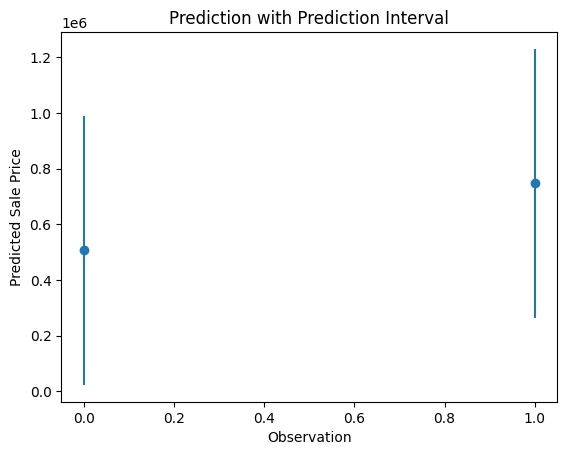

In [16]:
plt.errorbar(
    range(len(pred_summary)),
    pred_summary['mean'],
    yerr=[
        pred_summary['mean'] - pred_summary['obs_ci_lower'],
        pred_summary['obs_ci_upper'] - pred_summary['mean']
    ],
    fmt='o'
)

plt.xlabel('Observation')
plt.ylabel('Predicted Sale Price')
plt.title('Prediction with Prediction Interval')
plt.show()

### Why Intervals Matter

Satu nilai prediction dapat memberikan kesan seolah-olah model sangat
pasti.

Contohnya:

Predicted price = 500,000

Namun angka tersebut tidak menunjukkan uncertainty.

Dengan interval, kita dapat melihat bahwa prediction memiliki rentang
kemungkinan tertentu.

Karena itu, prediction interval memberikan informasi tambahan mengenai
ketidakpastian individual prediction.

# Factor Variables in Regression

## Dummy Variables Representation

Regression secara alami bekerja dengan variabel numerik.

Namun, dalam data sering terdapat variabel kategorikal atau factor
variables.

Contohnya:

PropertyType:
- Multiplex
- Single Family
- Townhouse

Kategori seperti ini perlu direpresentasikan dalam bentuk numerik agar
dapat digunakan dalam regression.

Salah satu caranya adalah menggunakan dummy variables.

## Melihat PropertyType

In [18]:
import pandas as pd

HOUSE_CSV = (
    'https://raw.githubusercontent.com/gedeck/'
    'practical-statistics-for-data-scientists/'
    'master/data/house_sales.csv'
)

house = pd.read_csv(HOUSE_CSV, sep='\t')

print(house.shape)
house.head()

(22687, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [19]:
print(house['PropertyType'].head())

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object


## Membuat Dummy Variables

In [20]:
print(
    pd.get_dummies(
        house['PropertyType'],
        dtype=int
    ).head(6)
)

   Multiplex  Single Family  Townhouse
1          1              0          0
2          0              1          0
3          0              1          0
4          0              1          0
5          0              1          0
6          0              0          1


## Drop First

In [21]:
print(
    pd.get_dummies(
        house['PropertyType'],
        drop_first=True,
        dtype=int
    ).head(6)
)

   Single Family  Townhouse
1              0          0
2              1          0
3              1          0
4              1          0
5              1          0
6              0          1


## Regression dengan Factor Variable

In [22]:
predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType'
]

outcome = 'AdjSalePrice'

X = pd.get_dummies(
    house[predictors],
    drop_first=True,
    dtype=int
)

In [23]:
from sklearn.linear_model import LinearRegression

house_lm_factor = LinearRegression()

house_lm_factor.fit(
    X,
    house[outcome]
)

LinearRegression()

In [24]:
print(f'Intercept: {house_lm_factor.intercept_:.3f}')

print('Coefficients:')

for name, coef in zip(
    X.columns,
    house_lm_factor.coef_
):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503828
 SqFtLot: -0.07036798136813083
 Bathrooms: -15979.013473415205
 Bedrooms: -50889.73218483025
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549257
 PropertyType_Townhouse: -115121.97921609184


## Factor Variables with Many Levels

Factor variables dapat memiliki banyak level.

Contohnya adalah ZipCode.

Jika setiap ZipCode dimasukkan sebagai dummy variable, jumlah predictor
dapat menjadi sangat banyak.

Hal tersebut dapat membuat model menjadi lebih kompleks dan sulit
diinterpretasikan.

Chapter ini menunjukkan pendekatan untuk menangani factor variable
dengan banyak level dengan menggunakan informasi residual dari model.

## Melihat Distribusi ZipCode

In [25]:
print(
    pd.DataFrame(
        house['ZipCode'].value_counts()
    ).transpose()
)

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


## Membuat Model Dasar

In [26]:
predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

house_lm = LinearRegression()

house_lm.fit(
    house[predictors],
    house[outcome]
)

LinearRegression()

## Menghitung Residual Berdasarkan ZipCode

In [27]:
zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual': (
        house[outcome]
        - house_lm.predict(house[predictors])
    ),
})

zip_residuals.head()

,ZipCode,residual
1,98002,-123750.814194
2,98166,-59145.413089
3,98166,190108.725716
4,98168,-198788.774412
5,98168,-91774.996129


## Median Residual per ZipCode

In [28]:
zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    }
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups.head()

,ZipCode,count,median_residual
36,98057,4,-537321.644462
27,98043,1,-307661.343614
46,98092,289,-193569.183599
23,98038,788,-150066.477035
31,98051,32,-142352.869593


## Membuat ZipGroup

In [29]:
zip_groups['cum_count'] = np.cumsum(
    zip_groups['count']
)

zip_groups['ZipGroup'] = pd.qcut(
    zip_groups['cum_count'],
    5,
    labels=False,
    retbins=False
)

zip_groups.head()

,ZipCode,count,median_residual,cum_count,ZipGroup
36,98057,4,-537321.644462,4,0
27,98043,1,-307661.343614,5,0
46,98092,289,-193569.183599,294,0
23,98038,788,-150066.477035,1082,0
31,98051,32,-142352.869593,1114,0


In [30]:
print(
    zip_groups.ZipGroup.value_counts().sort_index()
)

ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


## Menggabungkan ZipGroup ke Data

In [31]:
to_join = zip_groups[
    ['ZipCode', 'ZipGroup']
].set_index('ZipCode')

house = house.join(
    to_join,
    on='ZipCode'
)

house['ZipGroup'] = house['ZipGroup'].astype('category')

## Ordered Factor Variables

Tidak semua factor variables bersifat nominal.

Beberapa factor variables memiliki urutan yang bermakna.

Contohnya adalah tingkat kualitas bangunan.

Misalnya:

1 = Poor
2 = Fair
3 = Average
4 = Good
5 = Excellent

Pada ordered factor, urutan kategori memiliki informasi.

Karena itu, cara merepresentasikan ordered factor perlu mempertimbangkan
informasi urutan tersebut.

# Interpreting the Regression Equation

## Correlated Predictors

Dalam multiple linear regression, model dapat memiliki beberapa
predictor variables yang digunakan untuk menjelaskan suatu outcome.

Masalah dapat muncul ketika dua atau lebih predictor saling berkorelasi.

Contohnya pada data rumah:
- SqFtTotLiving
- Bedrooms
- Bathrooms

Rumah dengan luas bangunan yang lebih besar cenderung memiliki
jumlah kamar tidur dan kamar mandi yang lebih banyak.

Ketika predictor saling berkorelasi, koefisien regresi menjadi lebih
sulit untuk diinterpretasikan secara individual.

Koefisien suatu predictor menunjukkan perubahan pada outcome ketika
predictor tersebut berubah, dengan predictor lainnya dianggap tetap.

Oleh karena itu, korelasi antar-predictor perlu diperhatikan ketika
menginterpretasikan regression equation.

## Multicollinearity

Multicollinearity terjadi ketika predictor variables dalam regression
saling berkorelasi dengan kuat.

Multicollinearity dapat menyebabkan:
- koefisien regression menjadi tidak stabil,
- standard error menjadi lebih besar,
- interpretasi masing-masing predictor menjadi lebih sulit.

Dalam kondisi multicollinearity, model masih dapat menghasilkan
prediksi yang baik, tetapi interpretasi terhadap individual predictor
dapat menjadi bermasalah.

Oleh karena itu, ketika tujuan utama adalah menjelaskan hubungan
antara predictor dan outcome, hubungan antar-predictor perlu
diperhatikan.

## Reduced Model

In [41]:
print(f'Intercept: {best_model.intercept_:.3f}')

print('Coefficients:')

for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


## Model dengan Predictor yang Lebih Sedikit

In [42]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']

outcome = 'AdjSalePrice'

X = pd.get_dummies(
    house[predictors],
    drop_first=True,
    dtype=int
)

reduced_lm = LinearRegression()

reduced_lm.fit(
    X,
    house[outcome]
)

LinearRegression()

In [43]:
print(f'Intercept: {reduced_lm.intercept_:.3f}')

print('Coefficients:')

for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230215377
 BldgGrade: 248997.79366213758
 YrBuilt: -3211.7448621550866
 PropertyType_Single Family: -19898.495340502435
 PropertyType_Townhouse: -47355.4368733449


## Confounding Variables

Confounding terjadi ketika suatu variable berkaitan dengan predictor
dan juga berkaitan dengan outcome, sehingga hubungan antara predictor
dan outcome dapat menjadi sulit untuk diinterpretasikan.

Dalam data housing, lokasi atau ZipCode dapat berhubungan dengan
harga rumah.

Misalnya, rumah dengan karakteristik fisik yang sama dapat memiliki
harga berbeda karena berada di lokasi yang berbeda.

Karena itu, location dapat menjadi important variable ketika
menginterpretasikan hubungan antara karakteristik rumah dan harga.

## Reproduce Code — Confounding Variables

In [44]:
predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType',
    'ZipGroup'
]

outcome = 'AdjSalePrice'

X = pd.get_dummies(
    house[predictors],
    drop_first=True,
    dtype=int
)

confounding_lm = LinearRegression()

confounding_lm.fit(
    X,
    house[outcome]
)

LinearRegression()

In [45]:
print(f'Intercept: {confounding_lm.intercept_:.3f}')

print('Coefficients:')

for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580154
 SqFtLot: 0.45498713854658845
 Bathrooms: 5928.42564000163
 Bedrooms: -41682.87184074476
 BldgGrade: 98541.18352725972
 PropertyType_Single Family: 19323.6252879192
 PropertyType_Townhouse: -78198.720927624
 ZipGroup_1: 53317.17330659817
 ZipGroup_2: 116251.58883563551
 ZipGroup_3: 178360.53178793378
 ZipGroup_4: 338408.60185652034


## Interactions and Main Effects

Dalam regression, interaction terjadi ketika pengaruh suatu predictor
terhadap outcome bergantung pada nilai predictor lainnya.

Dengan kata lain, efek suatu predictor tidak selalu sama untuk semua
kelompok atau kondisi.

Contohnya dalam data rumah:

Pengaruh SqFtTotLiving terhadap AdjSalePrice dapat berbeda
berdasarkan ZipGroup.

Jika demikian, hubungan antara ukuran rumah dan harga tidak cukup
dijelaskan hanya dengan main effect dari SqFtTotLiving.

Model perlu memasukkan interaction antara:

SqFtTotLiving × ZipGroup

Main effect adalah efek masing-masing predictor secara individual,
sedangkan interaction effect menunjukkan bahwa efek satu predictor
bergantung pada predictor lainnya.

## Reproduce Code — Interactions and Main Effects

In [46]:
model = smf.ols(
    formula='AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + ' +
            'Bathrooms + Bedrooms + BldgGrade + PropertyType',
    data=house
)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:15:16   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

## Summary — Interpreting the Regression Equation

Bagian ini membahas bagaimana regression equation diinterpretasikan
ketika terdapat beberapa predictor.

1. Correlated Predictors
   Predictor yang saling berkorelasi dapat membuat interpretasi
   koefisien individual menjadi lebih sulit.

2. Multicollinearity
   Multicollinearity terjadi ketika predictor memiliki korelasi yang
   kuat satu sama lain. Kondisi ini dapat membuat koefisien menjadi
   tidak stabil dan standard error menjadi lebih besar.

3. Confounding Variables
   Confounding terjadi ketika variable lain berkaitan dengan predictor
   dan outcome sehingga hubungan antara predictor dan outcome menjadi
   lebih sulit diinterpretasikan.

4. Interactions and Main Effects
   Main effect menunjukkan efek predictor secara individual,
   sedangkan interaction menunjukkan bahwa efek suatu predictor
   dapat bergantung pada predictor lainnya.

Pada contoh housing data, ZipGroup digunakan untuk memperhitungkan
perbedaan lokasi dan interaction antara SqFtTotLiving dan ZipGroup
digunakan untuk melihat apakah hubungan ukuran rumah dengan harga
berbeda antar kelompok lokasi.

# Regression Diagnostics

Regression diagnostics digunakan untuk memeriksa apakah terdapat
masalah pada hasil regression.

Beberapa hal yang diperiksa antara lain:

1. Outliers
2. Influential Values
3. Heteroskedasticity
4. Non-Normality
5. Correlated Errors
6. Nonlinearity

Regression diagnostics membantu mengidentifikasi observasi atau pola
data yang dapat memengaruhi hasil regression.

## Outliers

Outlier adalah observasi yang memiliki nilai yang berbeda jauh dari
pola observasi lainnya.

Dalam regression, outlier dapat memiliki residual yang besar.

Residual merupakan selisih antara nilai aktual dan nilai yang
diprediksi oleh model:

Residual = Actual Value - Fitted Value

Untuk menganalisis outlier, statsmodels menyediakan berbagai tools,
salah satunya adalah OLSInfluence.

Studentized residual dapat digunakan untuk mengidentifikasi observasi
dengan residual yang relatif besar dibandingkan observasi lainnya.

## Menyiapkan Data 98105

In [47]:
house_98105 = house.loc[house['ZipCode'] == 98105, :]

predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

house_outlier = sm.OLS(
    house_98105[outcome],
    house_98105[predictors].assign(const=1)
)

result_98105 = house_outlier.fit()

print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          1.69e-103
Time:                        17:16:56   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

## Studentized Residual

In [48]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(result_98105)

sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

24333 -4.32673180407856


## Melihat Observasi Outlier

In [49]:
print(result_98105.resid.loc[sresiduals.idxmin()])

outlier = house_98105.loc[sresiduals.idxmin(), :]

print('AdjSalePrice', outlier[outcome])

print(outlier[predictors])

-757753.6192115822
AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


## Influential Values

Influential value adalah observasi yang memiliki pengaruh besar
terhadap hasil regression.

Sebuah observasi dapat menjadi influential karena memiliki kombinasi
karakteristik yang membuatnya sangat memengaruhi garis regression.

Influence dapat dianalisis menggunakan beberapa ukuran, salah satunya
adalah Cook's distance.

Cook's distance membantu mengukur seberapa besar perubahan hasil
regression apabila suatu observasi dikeluarkan dari model.

## Contoh Influential Value

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(5)

x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)

x[0] = 8
y[0] = 8

In [51]:
def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""

    x_vals = np.array(ax.get_xlim())

    return (
        x_vals,
        intercept + slope * x_vals
    )

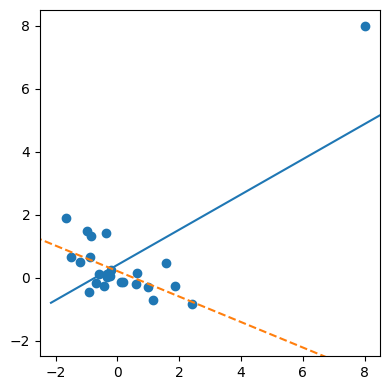

In [52]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(x, y)

slope, intercept, _, _, _ = linregress(x, y)

ax.plot(*abline(slope, intercept, ax))

slope, intercept, _, _, _ = linregress(
    x[1:],
    y[1:]
)

ax.plot(
    *abline(slope, intercept, ax),
    '--'
)

ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

## Cook's Distance

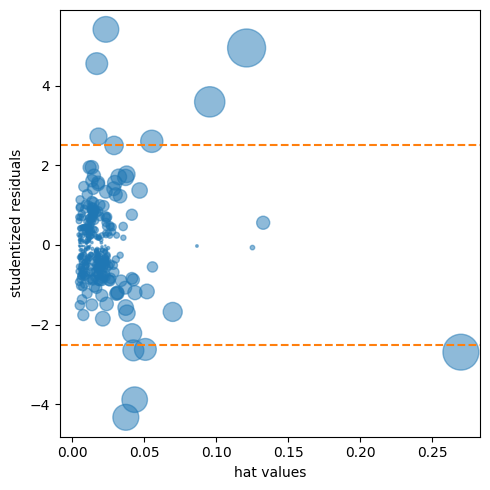

In [53]:
influence = OLSInfluence(result_98105)

fig, ax = plt.subplots(figsize=(5, 5))

ax.axhline(
    -2.5,
    linestyle='--',
    color='C1'
)

ax.axhline(
    2.5,
    linestyle='--',
    color='C1'
)

ax.scatter(
    influence.hat_matrix_diag,
    influence.resid_studentized_internal,
    s=1000 * np.sqrt(influence.cooks_distance[0]),
    alpha=0.5
)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

## Menghilangkan Influential Values

In [54]:
mask = [
    dist < .08
    for dist in influence.cooks_distance[0]
]

house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(
    house_infl[outcome],
    house_infl[predictors].assign(const=1)
)

result_infl = ols_infl.fit()

In [55]:
pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


## Heteroskedasticity, Non-Normality, and Correlated Errors

Selain outlier dan influential values, regression diagnostics juga
digunakan untuk melihat pola pada residual.

Tiga hal yang perlu diperhatikan adalah:

### Heteroskedasticity

Heteroskedasticity terjadi ketika variabilitas residual tidak konstan
pada seluruh rentang nilai prediksi.

### Non-Normality

Residual yang digunakan dalam berbagai analisis regression dapat
diperiksa apakah memiliki distribusi yang tidak terlalu menyimpang
dari asumsi normalitas.

### Correlated Errors

Residual dapat memiliki hubungan atau pola tertentu antar-observasi.
Hal ini dapat menunjukkan adanya correlated errors.

## Heteroskedasticity — Visualisasi

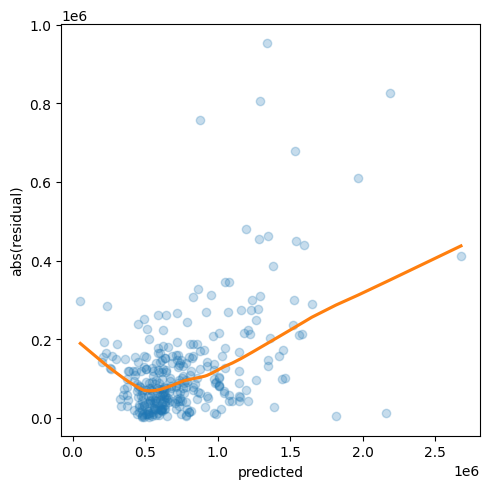

In [56]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

sns.regplot(
    x=result_98105.fittedvalues,
    y=np.abs(result_98105.resid),
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'C1'},
    lowess=True,
    ax=ax
)

ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

## Memeriksa Distribusi Residual

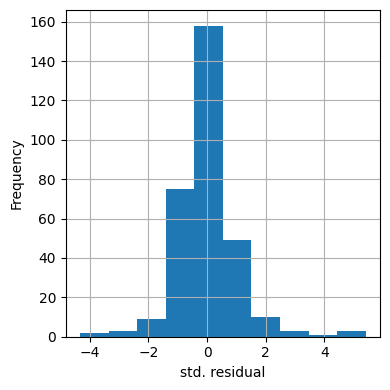

In [57]:
fig, ax = plt.subplots(figsize=(4, 4))

pd.Series(
    influence.resid_studentized_internal
).hist(ax=ax)

ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Partial Residual Plots and Nonlinearity

Partial residual plot digunakan untuk membantu melihat hubungan antara
suatu predictor dan outcome setelah mempertimbangkan predictor lainnya
dalam model.

Plot ini dapat digunakan untuk melihat kemungkinan adanya
nonlinearity.

Jika hubungan antara predictor dan outcome tidak mengikuti pola
linear, regression linear sederhana dapat kurang sesuai untuk
merepresentasikan hubungan tersebut.

## Partial Residual Plot

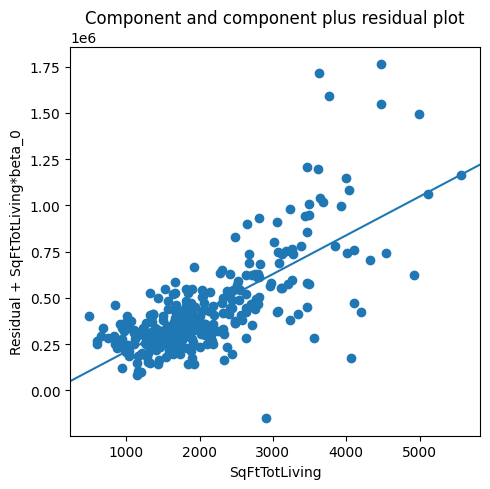

In [58]:
fig, ax = plt.subplots(figsize=(5, 5))

fig = sm.graphics.plot_ccpr(
    result_98105,
    'SqFtTotLiving',
    ax=ax
)

plt.tight_layout()
plt.show()

## Partial Residual Plot untuk Semua Predictor

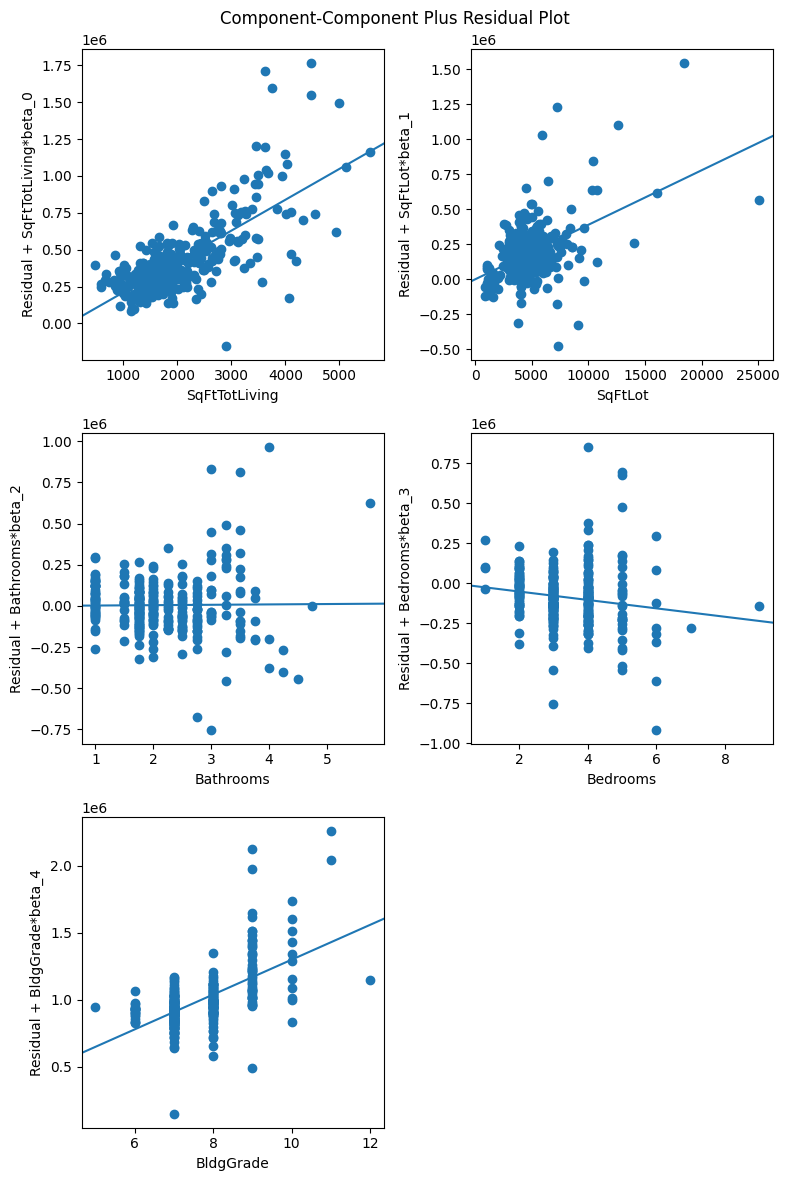

In [59]:
fig = plt.figure(figsize=(8, 12))

fig = sm.graphics.plot_ccpr_grid(
    result_98105,
    fig=fig
)

plt.tight_layout()
plt.show()

# Summary — Regression Diagnostics

Regression diagnostics digunakan untuk memeriksa masalah yang dapat
memengaruhi regression model.

Hal-hal utama yang diperiksa:

1. Outliers
   Observasi dengan residual yang sangat besar dapat menjadi outlier.

2. Influential Values
   Beberapa observasi dapat memberikan pengaruh yang besar terhadap
   hasil regression. Cook's distance dapat digunakan untuk membantu
   mengidentifikasi pengaruh tersebut.

3. Heteroskedasticity
   Variabilitas residual dapat berbeda pada berbagai tingkat nilai
   prediksi.

4. Non-Normality
   Distribusi residual dapat diperiksa untuk melihat adanya pola yang
   tidak sesuai dengan asumsi yang digunakan dalam analisis.

5. Correlated Errors
   Residual dapat memiliki hubungan atau pola antar-observasi.

6. Nonlinearity
   Partial residual plots dapat digunakan untuk membantu melihat
   apakah hubungan antara predictor dan outcome menunjukkan pola
   non-linear.

Regression diagnostics membantu memahami kualitas dan karakteristik
model, bukan hanya melihat nilai koefisien regression.

# Polynomial Regression

Polynomial regression digunakan ketika hubungan antara predictor dan response
tidak berbentuk garis lurus.

Pada linear regression biasa, hubungan antara predictor X dan response Y
dimodelkan sebagai:

Y = β₀ + β₁X

Pada polynomial regression, kita dapat menambahkan pangkat dari X,
misalnya X²:

Y = β₀ + β₁X + β₂X²

Dengan demikian, model dapat menangkap hubungan yang melengkung
(non-linear) antara predictor dan response.

Dalam contoh ini, kita menggunakan:
- AdjSalePrice sebagai response
- SqFtTotLiving sebagai predictor utama
- SqFtLot, Bathrooms, Bedrooms, dan BldgGrade sebagai predictor lainnya.

Polynomial regression memungkinkan pengaruh SqFtTotLiving terhadap
AdjSalePrice berubah secara non-linear.

## Polynomial Regression — Code Buku

In [60]:
model_poly = smf.ols(
    formula='AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + ' +
    'SqFtLot + Bathrooms + Bedrooms + BldgGrade',
    data=house_98105
)

result_poly = model_poly.fit()

print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        17:23:08   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Interpretasi Polynomial Regression

Pada polynomial regression, koefisien SqFtTotLiving dan
SqFtTotLiving² harus dipahami secara bersama-sama.

Koefisien SqFtTotLiving menunjukkan kontribusi linear,
sedangkan SqFtTotLiving² memungkinkan hubungan tersebut
berubah mengikuti bentuk kurva.

Jika koefisien kuadrat berbeda dari nol, model dapat menangkap
pola non-linear antara luas rumah dan harga rumah.

Polynomial regression tetap menggunakan linear regression
dalam parameter model, tetapi predictor-nya dapat berupa
transformasi polynomial seperti X².

## Partial Residual Plot

Partial residual plot digunakan untuk melihat hubungan antara
suatu predictor dengan response setelah pengaruh predictor
lainnya diperhitungkan.

Pada bagian ini, partial residual plot digunakan untuk melihat
hubungan antara SqFtTotLiving dan AdjSalePrice pada model
polynomial regression.

Plot ini membantu melihat apakah hubungan antara predictor
dan response lebih sesuai digambarkan sebagai hubungan linear
atau memiliki pola non-linear.

In [61]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)

    required = set(model.params.index).intersection(df.columns)
    required.add(feature)

    copy_df = df[list(required)].copy().astype('float')

    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0

    feature_prediction = model.predict(copy_df)

    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params[0],
    })

    results = results.sort_values(by=['feature'])

    smoothed = sm.nonparametric.lowess(
        results.ypartial + results.residual,
        results.feature,
        frac=1/3
    )

    ax.scatter(
        results.feature,
        results.ypartial + results.residual
    )

    ax.plot(
        smoothed[:, 0],
        smoothed[:, 1],
        color='gray'
    )

    ax.plot(
        results.feature,
        results.ypartial,
        color='black'
    )

    ax.set_xlabel(feature)
    ax.set_ylabel(
        f'Residual + {feature} contribution'
    )

    return ax

## Plot Polynomial Regression

/tmp/ipykernel_468/1906277927.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ypartial': feature_prediction - model.params[0],


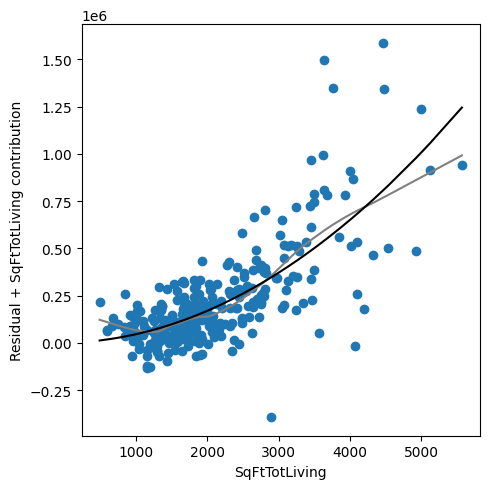

In [62]:
fig, ax = plt.subplots(figsize=(5, 5))

partialResidualPlot(
    result_poly,
    house_98105,
    'AdjSalePrice',
    'SqFtTotLiving',
    ax
)

plt.tight_layout()
plt.show()

In [63]:
print(result_poly.params[2])

0.03879128168231146


/tmp/ipykernel_468/2053320695.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(result_poly.params[2])


In [64]:
print(result_poly.params)

Intercept                    -615850.841791
SqFtTotLiving                      7.452134
np.power(SqFtTotLiving, 2)         0.038791
SqFtLot                           32.559355
Bathrooms                      -1435.123106
Bedrooms                       -9191.944128
BldgGrade                     135717.060127
dtype: float64


## Splines

Spline regression digunakan untuk memodelkan hubungan non-linear
dengan membagi rentang predictor menjadi beberapa bagian.

Berbeda dengan polynomial regression yang menggunakan satu
persamaan polynomial untuk seluruh rentang data, spline
menggunakan beberapa fungsi polynomial yang dihubungkan pada
titik tertentu yang disebut knots.

Dalam contoh ini, spline digunakan untuk memodelkan hubungan
antara SqFtTotLiving dan AdjSalePrice.

Model menggunakan:
- bs(SqFtTotLiving, df=6, degree=3)
- SqFtLot
- Bathrooms
- Bedrooms
- BldgGrade

Parameter df dan degree mengontrol fleksibilitas spline.

## Spline Regression

In [65]:
formula = (
    'AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' +
    'SqFtLot + Bathrooms + Bedrooms + BldgGrade'
)

model_spline = smf.ols(
    formula=formula,
    data=house_98105
)

result_spline = model_spline.fit()

print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        17:25:38   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Partial Residual Plot pada Spline

/tmp/ipykernel_468/1906277927.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ypartial': feature_prediction - model.params[0],


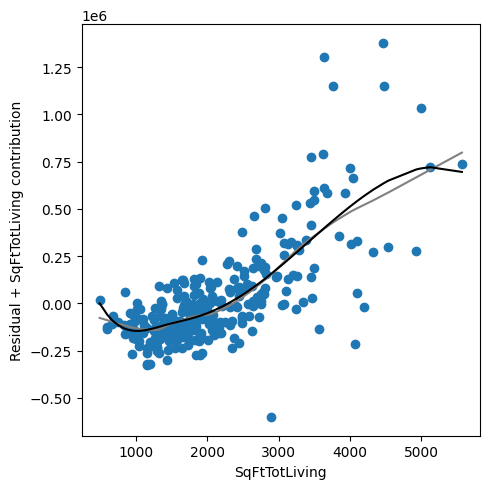

In [66]:
fig, ax = plt.subplots(figsize=(5, 5))

partialResidualPlot(
    result_spline,
    house_98105,
    'AdjSalePrice',
    'SqFtTotLiving',
    ax
)

plt.tight_layout()
plt.show()

## Generalized Additive Models (GAM)

Generalized Additive Model (GAM) memungkinkan hubungan antara
response dan beberapa predictor dimodelkan menggunakan fungsi
yang berbeda untuk setiap predictor.

Pada contoh ini digunakan:
- SqFtTotLiving sebagai spline term
- SqFtLot sebagai linear term
- Bathrooms sebagai linear term
- Bedrooms sebagai linear term
- BldgGrade sebagai linear term

GAM memungkinkan model menangkap hubungan non-linear pada
predictor tertentu tanpa harus membuat seluruh model menjadi
polynomial.

## Menyiapkan Data GAM

In [67]:
predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

X = house_98105[predictors].values
y = house_98105[outcome]

In [68]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (313, 5)
Shape y: (313,)


## Membuat GAM

In [70]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.9 MB/s eta 0:00:00


In [74]:
gam = LinearGAM(
    s(0, n_splines=12) +
    l(1) +
    l(2) +
    l(3) +
    l(4)
)

gam.gridsearch(X, y)

print(gam.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -4213.0332
Number of Samples:                          313 AIC:                                             8443.4209
                                                AICc:                                            8443.9746
                                                GCV:                                      30838885095.1676
                                                Scale:                                         171698.5198
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

/tmp/ipykernel_468/3710827193.py:11: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


## Visualisasi GAM

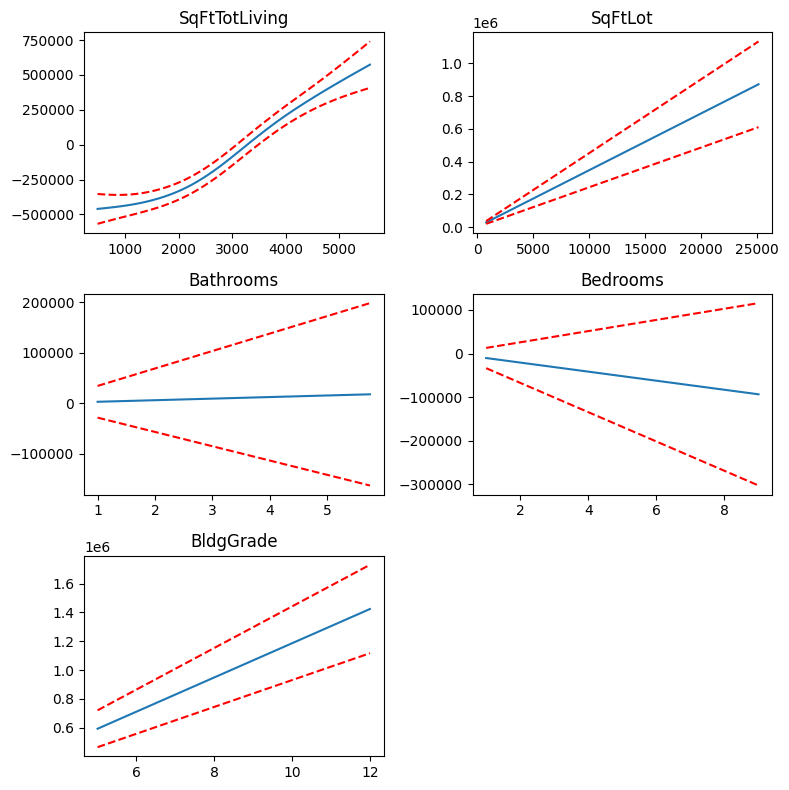

In [75]:
fig, axes = plt.subplots(
    figsize=(8, 8),
    ncols=2,
    nrows=3
)

titles = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]

    XX = gam.generate_X_grid(term=i)

    ax.plot(
        XX[:, i],
        gam.partial_dependence(
            term=i,
            X=XX
        )
    )

    ax.plot(
        XX[:, i],
        gam.partial_dependence(
            term=i,
            X=XX,
            width=.95
        )[1],
        c='r',
        ls='--'
    )

    ax.set_title(titles[i])

axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

## Summary — Polynomial and Spline Regression

Bagian ini membahas beberapa cara untuk memodelkan hubungan
non-linear dalam regression.

1. Polynomial Regression
   Menggunakan pangkat predictor seperti X² untuk menangkap
   hubungan yang melengkung.

2. Splines
   Membagi rentang predictor menjadi beberapa bagian dan
   menggunakan polynomial yang saling terhubung.

3. Generalized Additive Models (GAM)
   Memungkinkan setiap predictor memiliki bentuk hubungan
   yang berbeda terhadap response, misalnya spline untuk
   satu predictor dan hubungan linear untuk predictor lainnya.

Metode-metode tersebut digunakan ketika hubungan antara
predictor dan response tidak cukup dijelaskan oleh garis lurus.

# Summary — Regression and Prediction

Regression is used to model the relationship between a response
variable and one or more predictor variables.

Simple linear regression uses one predictor and assumes a linear
relationship between the predictor and the response.

Multiple linear regression extends this approach by using several
predictors simultaneously.

Regression can be used for both prediction and explanation.
However, prediction outside the range of the observed data can
lead to unreliable extrapolation.

Factor variables can be incorporated into regression using
dummy variables. This allows categorical variables to be included
as predictors.

Regression diagnostics are important for identifying problems
with a regression model. These include outliers, influential
observations, heteroskedasticity, non-normality, correlated
errors, and nonlinearity.

Polynomial regression and spline regression provide ways to
model non-linear relationships. Generalized Additive Models (GAM)
allow different predictors to have different functional forms.

The main ideas covered in this chapter are:

- Simple linear regression
- Multiple linear regression
- Prediction using regression
- Factor variables
- Interpreting regression coefficients
- Regression diagnostics
- Polynomial regression
- Spline regression
- Generalized Additive Models

## Key Ideas

### 1. Regression
Regression models the relationship between a response variable
and one or more predictor variables.

### 2. Simple Linear Regression
Uses one predictor:

Y = β₀ + β₁X

The coefficient β₁ represents the change in the predicted response
associated with a one-unit change in X.

### 3. Multiple Linear Regression
Uses multiple predictors:

Y = β₀ + β₁X₁ + β₂X₂ + ... + βpXp

Each coefficient represents the contribution of a predictor while
holding the other predictors constant.

### 4. Residuals
A residual is the difference between the observed value and the
fitted value:

Residual = Observed − Fitted

Residuals are useful for evaluating regression model assumptions.

### 5. R²
R² describes the proportion of variation in the response that is
accounted for by the regression model.

### 6. Factor Variables
Categorical variables can be represented using dummy variables
so that they can be included in a regression model.

### 7. Regression Diagnostics
Diagnostics help identify:
- Outliers
- Influential observations
- Heteroskedasticity
- Non-normality
- Correlated errors
- Nonlinearity

### 8. Polynomial Regression
Polynomial terms such as X² can be added to capture non-linear
relationships.

### 9. Splines
Splines model non-linear relationships using connected polynomial
functions over different regions of the predictor.

### 10. Generalized Additive Models
GAM allows different predictors to have different functional forms,
including smooth non-linear functions.

## Kesimpulan

Chapter 4 membahas regression sebagai metode untuk memahami dan
memprediksi hubungan antara response variable dan predictor
variables.

Pembahasan dimulai dari simple linear regression dan dilanjutkan
ke multiple linear regression. Chapter ini juga membahas penggunaan
regression untuk prediction, factor variables, interpretasi
koefisien, serta berbagai regression diagnostics.

Ketika hubungan antara predictor dan response tidak bersifat
linear, polynomial regression, spline regression, dan generalized
additive models dapat digunakan untuk memodelkan pola tersebut.

Dengan demikian, pemilihan dan evaluasi model regression tidak
hanya bergantung pada kemampuan model menghasilkan prediksi,
tetapi juga pada pemeriksaan asumsi dan karakteristik data.